In [21]:
import pandas as pd
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')

# Tímhle se přeskočí celý preprocessing!
X_train_prep, X_test_prep, y_train, y_test = joblib.load('../data/processed/split_data.pkl')

In [22]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),
}
scaled_models = {'Logistic Regression'}

In [23]:
smote = SMOTE(random_state=42)
results = {}

for name, model in models.items():
    X_tr_resampled, y_train_resampled = smote.fit_resample(X_train_prep, y_train)
    model.fit(X_tr_resampled, y_train_resampled)

    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1]

    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred),
        'y_pred': y_pred,
    }

    print(f"{'=' * 50}")
    print(f"  {name}")
    print(f"{'=' * 50}")
    print(f"  Accuracy : {results[name]['accuracy']:.4f}")
    print(f"  ROC-AUC  : {results[name]['roc_auc']:.4f}")
    print(f"\n{results[name]['report']}")

  Logistic Regression
  Accuracy : 0.7480
  ROC-AUC  : 0.7981

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1529
           1       0.48      0.69      0.56       471

    accuracy                           0.75      2000
   macro avg       0.68      0.73      0.69      2000
weighted avg       0.79      0.75      0.76      2000

  Random Forest
  Accuracy : 0.7795
  ROC-AUC  : 0.7972

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1529
           1       0.53      0.59      0.56       471

    accuracy                           0.78      2000
   macro avg       0.70      0.71      0.71      2000
weighted avg       0.79      0.78      0.78      2000

  Gradient Boosting
  Accuracy : 0.7920
  ROC-AUC  : 0.8009

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1529
           1       0.57      0.49      0.53       471

 

In [24]:
cols_to_drop_gpa = ['CGPA', 'GPA_trend']
X_train_wo_gpa = X_train_prep.drop(columns=cols_to_drop_gpa, errors='ignore')
X_test_wo_gpa = X_test_prep.drop(columns=cols_to_drop_gpa, errors='ignore')

results_wo_gpa = {}

for name, model in models.items():
    X_tr_resampled, y_train_resampled = smote.fit_resample(X_train_wo_gpa, y_train)

    model.fit(X_tr_resampled, y_train_resampled)

    y_pred = model.predict(X_test_wo_gpa)
    y_proba = model.predict_proba(X_test_wo_gpa)[:, 1]

    results_wo_gpa[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred),
    }

    print(f"\n{'=' * 50}")
    print(f"  {name} (Bez GPA)")
    print(f"{'=' * 50}")
    print(f"  Accuracy : {results_wo_gpa[name]['accuracy']:.4f}")
    print(f"  ROC-AUC  : {results_wo_gpa[name]['roc_auc']:.4f}")
    print(f"\n{results_wo_gpa[name]['report']}")


  Logistic Regression (Bez GPA)
  Accuracy : 0.6640
  ROC-AUC  : 0.6908

              precision    recall  f1-score   support

           0       0.84      0.69      0.76      1529
           1       0.36      0.58      0.45       471

    accuracy                           0.66      2000
   macro avg       0.60      0.63      0.60      2000
weighted avg       0.73      0.66      0.69      2000


  Random Forest (Bez GPA)
  Accuracy : 0.7585
  ROC-AUC  : 0.6919

              precision    recall  f1-score   support

           0       0.80      0.91      0.85      1529
           1       0.48      0.28      0.36       471

    accuracy                           0.76      2000
   macro avg       0.64      0.59      0.60      2000
weighted avg       0.73      0.76      0.73      2000


  Gradient Boosting (Bez GPA)
  Accuracy : 0.7780
  ROC-AUC  : 0.7033

              precision    recall  f1-score   support

           0       0.80      0.95      0.87      1529
           1       0.58

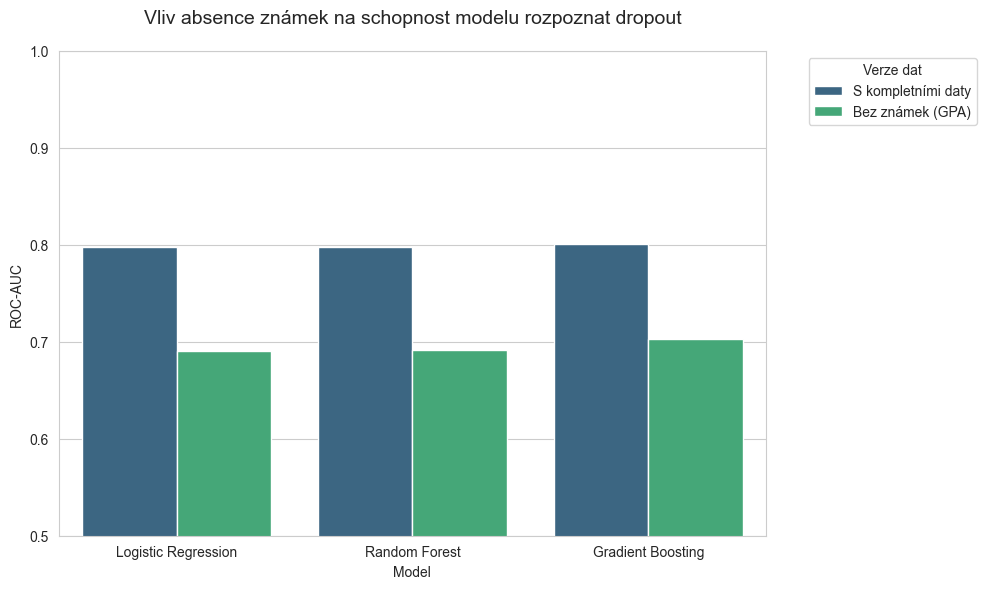

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = []
for model_name in results.keys():
    plot_data.append({'Model': model_name, 'ROC-AUC': results[model_name]['roc_auc'], 'Typ': 'S kompletními daty'})
    if model_name in results_wo_gpa:
        plot_data.append(
            {'Model': model_name, 'ROC-AUC': results_wo_gpa[model_name]['roc_auc'], 'Typ': 'Bez známek (GPA)'})

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.barplot(data=df_plot, x='Model', y='ROC-AUC', hue='Typ', palette='viridis')

plt.title('Vliv absence známek na schopnost modelu rozpoznat dropout', fontsize=14, pad=20)
plt.ylim(0.5, 1.0)
plt.ylabel('ROC-AUC')
plt.legend(title='Verze dat', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

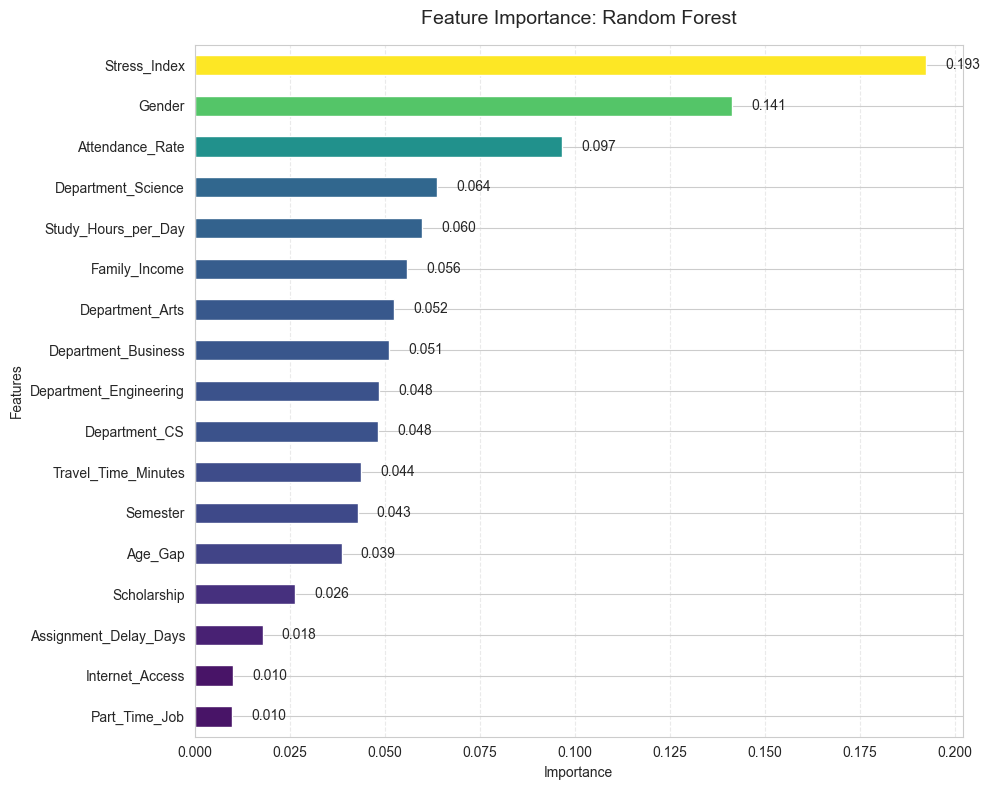

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

target_results = results
model_name = 'Random Forest'
best_model = target_results[model_name]['model']

importances = best_model.feature_importances_

if len(importances) == len(X_train_prep.columns):
    features = X_train_prep.columns
else:
    features = X_train_wo_gpa.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(feat_imp.values / max(feat_imp.values))
feat_imp.plot(kind='barh', color=colors)

plt.title(f'Feature Importance: {model_name}', fontsize=14, pad=15)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.4)

for i, v in enumerate(feat_imp.values):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

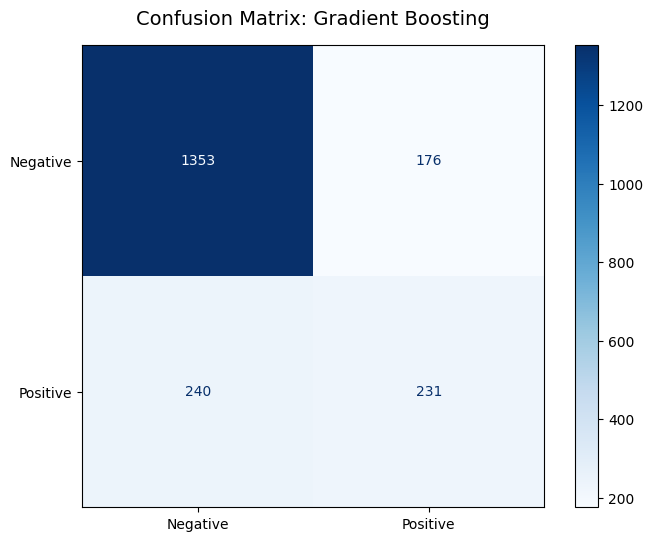

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams.update({
    'text.color': "black",
    'axes.labelcolor': "black",
    'xtick.color': "black",
    'ytick.color': "black",
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

model_name = 'Gradient Boosting'
y_pred_gb = results[model_name]['y_pred']
cm = confusion_matrix(y_test, y_pred_gb)

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

ax.set_xlabel('')
ax.set_ylabel('')

plt.title(f'Confusion Matrix: {model_name}', fontsize=14, pad=15, color='black')
plt.grid(False)
plt.show()

In [28]:
param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l2'],
        'model__class_weight': [None, 'balanced']
    },
    'Random Forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [5, 10, 15, None],
        'model__min_samples_split': [2, 5, 10]
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 4, 5]
    }
}

print("Spouštím ladění hyperparametrů (Hyperparameter Tuning)...\n")

best_tuned_models = {}
overall_best_model = None
overall_best_score = 0
winning_name = ""

for name, model in models.items():
    print(f"🔄 Ladím: {name}")

    # SPECIÁLNÍ TRIK: SMOTE musí být v rouře, aby nedošlo k Data Leakage při Cross-Validaci!
    tuning_pipeline = ImbPipeline(steps=[
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    # Použijeme RandomizedSearchCV (vyzkouší 10 náhodných kombinací z mřížky)
    search = RandomizedSearchCV(
        tuning_pipeline,
        param_distributions=param_grids[name],
        n_iter=10,
        scoring='roc_auc',
        cv=3, # 3-fold cross validation
        random_state=42,
        n_jobs=-1 # Využije všechna jádra procesoru
    )

    # Trénujeme rovnou na datech z našeho prvního preprocesoru
    search.fit(X_train_prep, y_train)

    # Uložení nejlepší verze daného modelu
    best_tuned_models[name] = search.best_estimator_
    print(f"   Nejlepší parametry: {search.best_params_}")
    print(f"   Nejlepší ROC-AUC : {search.best_score_:.4f}\n")

    # Hledání absolutního vítěze
    if search.best_score_ > overall_best_score:
        overall_best_score = search.best_score_
        overall_best_model = search.best_estimator_
        winning_name = name

print("==================================================")
print(f"🏆 ABSOLUTNÍ VÍTĚZ: {winning_name} (ROC-AUC: {overall_best_score:.4f})")
print("==================================================")

# Tento absolutní vítěz se uloží pro Martina (Byznys) a pro Tebe (XAI)
joblib.dump(overall_best_model, '../models/best_tuned_model.pkl')
print("✅ Vítězný model bezpečně uložen do složky models/ jako 'best_tuned_model.pkl'")

Spouštím ladění hyperparametrů (Hyperparameter Tuning)...

🔄 Ladím: Logistic Regression
   Nejlepší parametry: {'model__penalty': 'l2', 'model__class_weight': None, 'model__C': 0.01}
   Nejlepší ROC-AUC : 0.8000

🔄 Ladím: Random Forest
   Nejlepší parametry: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__max_depth': 10}
   Nejlepší ROC-AUC : 0.7926

🔄 Ladím: Gradient Boosting
   Nejlepší parametry: {'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.05}
   Nejlepší ROC-AUC : 0.7964

🏆 ABSOLUTNÍ VÍTĚZ: Logistic Regression (ROC-AUC: 0.8000)
✅ Vítězný model bezpečně uložen do složky models/ jako 'best_tuned_model.pkl'
